In [2]:
#importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Ezekiel\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Apr  2 10:40:05 2026).


In [ ]:
df

In [3]:
df_us = df[df['job_country']== 'United States'].copy()

In [ ]:
df_us.info()

In [8]:
df_us['job_posted_month']= df_us['job_posted_date'].dt.strftime('%B')

df_us['job_posted_month'].head()

0        June
3        July
5    November
6       March
9       April
Name: job_posted_month, dtype: str

In [38]:
df_us_pivot= df_us.pivot_table(index='job_posted_month', columns='job_title_short' ,aggfunc='size')

In [39]:
df_us_pivot = df_us_pivot.reset_index()
df_us_pivot['month_no']= pd.to_datetime(df_us_pivot['job_posted_month'], format= '%B').dt.month
df_us_pivot= df_us_pivot.sort_values('month_no')
df_us_pivot= df_us_pivot.set_index('job_posted_month')
df_us_pivot= df_us_pivot.drop(columns='month_no')

In [40]:
df_us_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [51]:
top_3 = df_us['job_title_short'].value_counts().head(3)

In [53]:
top_3= top_3.index.to_list()
top_3

['Data Analyst', 'Data Scientist', 'Data Engineer']

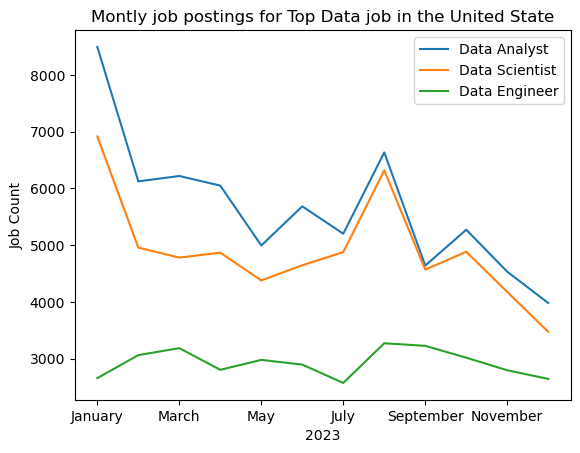

In [57]:
df_us_pivot[top_3].plot(kind='line')
plt.title('Montly job postings for Top Data job in the United State')
plt.ylabel('Job Count')
plt.xlabel(2023)
plt.legend()
plt.show()